In [1]:
import os
import numpy as np
import pickle
import matplotlib.pyplot as plt
import globals as gl

Base directory found: /cifs/diedrichsen/data/SensoriMotorPrediction/
Base directory: /cifs/diedrichsen/data/SensoriMotorPrediction/


In [3]:
experiment = 'smp0'
epochs = ['Pre', 'SLR', 'LLR', 'Vol']

group estimate:-0.9999999926874555 central 95% CI for r: [-1.000, 1.000]
Geom mean of variances: 2.602936669104334e-07, SD_err=1.4283562482995698; No reliable signal, discarding bootstrap resample
group estimate:-0.036143379356713426 central 95% CI for r: [-1.000, 0.719]
group estimate:0.646110329902124 central 95% CI for r: [0.370, 0.850]
group estimate:0.7740201256714457 central 95% CI for r: [0.673, 0.896]


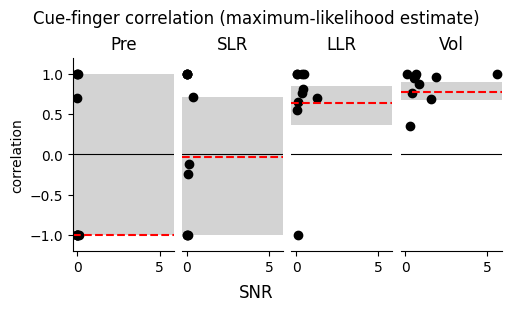

In [4]:
from vis import plot_pcm_corr

f = open(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, f'M.plan-exec.p'), "rb")
Mflex = pickle.load(f)

fig, axs = plt.subplots(1, len(epochs), sharex=True, sharey=True, figsize=(5, 3), constrained_layout=True)

for r, epoch in enumerate(epochs):
    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.corr_cue-finger.emg.{epoch}.p'), 'rb')
    theta = pickle.load(f)[0]
    r_bootstrap = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'r_bootstrap.corr_cue-finger.emg.{epoch}.npy'))
    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_gr.corr_cue-finger.emg.{epoch}.p'), 'rb')
    theta_g = pickle.load(f)[0]
    fig, axs = plot_pcm_corr(fig, axs, r, Mflex, theta, theta_g, r_bootstrap)
    axs[r].set_title(epoch)

fig.supxlabel('SNR')
axs[0].set_ylabel('correlation')

fig.suptitle(f'Cue-finger correlation (maximum-likelihood estimate)')

plt.show()
